# <span style="color:darkblue"> QTM 151 Final Project: Time Analysis </span>

# <span style="color:darkblue"> I. Team Members </span>

In [2]:
print("Grace Chen, Matthew Dang, Lynne Zheng")

Grace Chen, Matthew Dang, Lynne Zheng


# <span style="color:darkblue"> II. Introduction </span>

In [4]:
#  A markdown text with 1-2 paragraph that summarize the main goals of the project. The first paragraph should briefly describe what Formula 1 is, what
# question you’re interested in, and why it is relevant. The introduction should end
# with a high-level description of the results and the coming structure of the
# project. Try to make the text self-contained, intended for someone who isn’t
# familiar with Formula 1 or the dataset.

<font size = "4">
Formula 1, or also known as F1, is the world's most popular motorsport racing circuit. The best drivers around the world sign with teams to compete, all with their own special cars and pit crews to give them a competitive edge. In order to get a better understanding of race times in F1, we decided to do our project on Time Analysis Tables. There are many variables that correlate to times, such as pit stop durations, time trends over different race events, and how times have improved over time due to technology and the sharpening of driver skill. 

<font size = "4">
Our final project will mainly answer two questions:<br>

- **Question 1**: Have lap times improved significantly over the years?<br>

- **Question 2**: Are pit stop durations correlated with race outcomes?

# <span style="color:darkblue"> III. Data Description </span>

<font size = "5">
Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import os

<font size = "5">
Import Data

In [2]:
races = pd.read_csv("data_raw/races.csv")
lap_times = pd.read_csv("data_raw/lap_times.csv")
pit_stops = pd.read_csv("data_raw/pit_stops.csv")

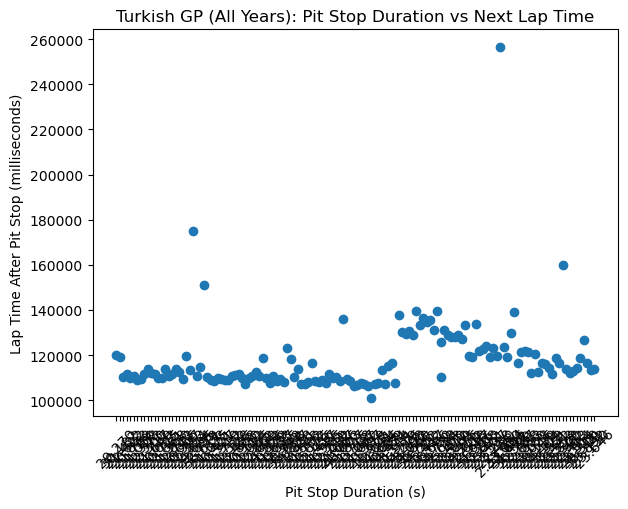

In [25]:
turkishgp = races[races['name'].str.contains('Turkish', case=False)]
turkeyraceids = turkishgp['raceId'].tolist()
turkeypitstops = pit_stops[pit_stops['raceId'].isin(turkeyraceids)]
turkeylaptimes = lap_times[lap_times['raceId'].isin(turkeyraceids)]
turkeypitstops = turkeypitstops.dropna(subset=['duration'])
pit_lap_merge = pd.merge(
    turkeypitstops,
    turkeylaptimes,
    on=['raceId', 'driverId'],
    how='inner'
)
pit_lap_merge = pit_lap_merge[pit_lap_merge['lap_y'] == pit_lap_merge['lap_x'] + 1]
pit_lap_merge = pit_lap_merge.rename(columns={
    'lap_x': 'pit_lap',
    'lap_y': 'lap_after_pit',
    'time_y': 'lap_time',
    'milliseconds_y': 'lap_time_milliseconds'
})
plt.scatter(pit_lap_merge['duration'], pit_lap_merge['lap_time_milliseconds'])
plt.xlabel('Pit Stop Duration (s)')
plt.ylabel('Lap Time After Pit Stop (milliseconds)')
plt.title('Turkish GP (All Years): Pit Stop Duration vs Next Lap Time')
plt.tight_layout() 
plt.xticks(rotation=45)
plt.show()


# <span style="color:darkblue"> IV. Results </span>

# <span style="color:darkblue"> V. Discussion </span>